The goal of this model is to test each pair of major airline stocks for cointegration (underlying driver "pulling" the prices together) and then select the most cointegrated pair, build a mean-reversion trading signal (we bet that the two stocks come back together, and short the one that got expensive and buy the one that got cheap) from their price spread, and backtest it out-of-sample with transaction costs to see if it's genuinely profitable rather than overfit.

In [2]:
import yfinance as yf
import pandas as pd

tickers = ["DAL", "UAL", "AAL", "LUV", "ALK", "JBLU"]

data = yf.download(tickers, start="2019-01-01", end="2026-09-01")["Close"]
data = data.dropna()
data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAL,ALK,DAL,JBLU,LUV,UAL
Date,,,,,,
2019-01-02,31.963158,59.860050,46.748058,16.200001,42.530933,84.180000
2019-01-03,29.581665,56.551785,42.566952,15.930000,41.150524,80.000000
2019-01-04,31.530161,58.381065,44.601517,16.549999,43.180534,82.680000
2019-01-07,32.425678,58.497826,44.657501,16.690001,43.189552,83.230003
2019-01-08,31.904110,59.013523,44.302856,16.850000,42.891819,82.379997


Cointegration is a statistical property that shows a long-term economic or financial relationship between two or more non-stationary time series variables

In [3]:
split_point = int(len(data) * 0.7) #Getting the 70th percentile row from where we will split the time-series data into in_sample and out_sample
in_sample = data.iloc[:split_point]
out_sample = data.iloc[split_point:]

print("In-sample:", in_sample.index[0], "to", in_sample.index[-1])
print("Out-of-sample:", out_sample.index[0], "to", out_sample.index[-1])

In-sample: 2019-01-02 00:00:00 to 2024-05-09 00:00:00
Out-of-sample: 2024-05-10 00:00:00 to 2026-08-31 00:00:00


So we build our strategy from 2019 2nd Jan till 9th May 2024, and apply it on the data from 10th May 2024 till 31st August 2026

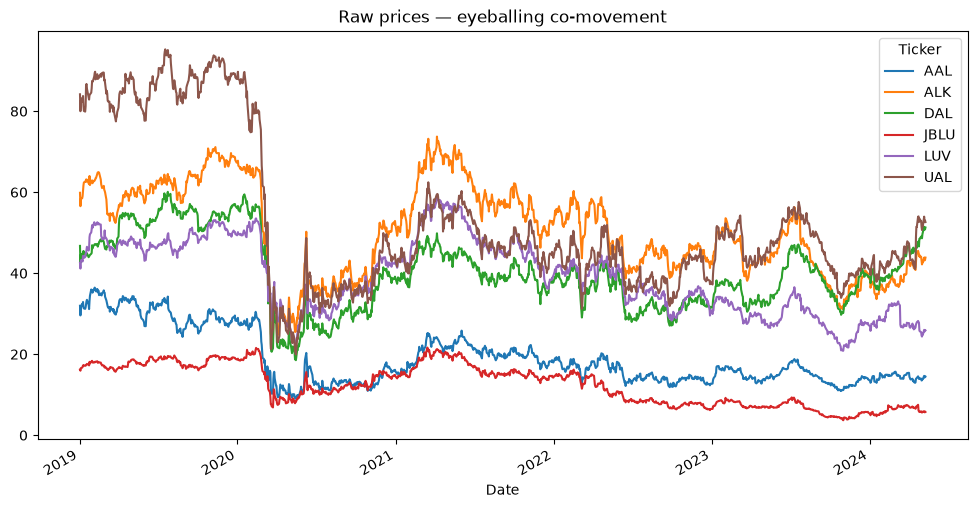

In [4]:
import matplotlib.pyplot as plt
in_sample.plot(figsize=(12,6))
plt.title("Raw prices — eyeballing co-movement")
plt.show()

From the graph above, it seems that ALK and UAL are the most cointegrated pair. Let's test this

In [5]:
from statsmodels.tsa.stattools import coint
import itertools

results = []
for i in range(len(tickers)-1):
    j=i+1
    while j<len(tickers):
        score, pvalue, _ = coint(in_sample[tickers[i]], in_sample[tickers[j]])
        results.append((tickers[i], tickers[j], pvalue))
        j+=1

pairs_df = pd.DataFrame(results, columns=["stock1", "stock2", "pvalue"])
pairs_df = pairs_df.sort_values("pvalue")
pairs_df.head(10)

,stock1,stock2,pvalue
13,LUV,JBLU,0.006665
12,LUV,ALK,0.144024
9,AAL,LUV,0.307739
0,DAL,UAL,0.307779
11,AAL,JBLU,0.333851
14,ALK,JBLU,0.340737
10,AAL,ALK,0.393690
1,DAL,AAL,0.571628
5,UAL,AAL,0.659533
6,UAL,LUV,0.712099


The lower the p-value the closer fit - and from the above table we see LUV and JBLU are the most cointegrated pair.

Now we find the hedge ratio which tells us, roughly, for every 1 share of JBLU, how many shares of LUV we should trade to properly balance the position.

In [6]:
import statsmodels.api as sm

stock1, stock2 = "LUV", "JBLU"

X = sm.add_constant(in_sample[stock2])
model = sm.OLS(in_sample[stock1], X).fit()
hedge_ratio = model.params[stock2]
print("Hedge ratio:", hedge_ratio)

Hedge ratio: 1.7640589841934566


Now we calculate the spread (gap). We are betting that the spread averages around some constant.

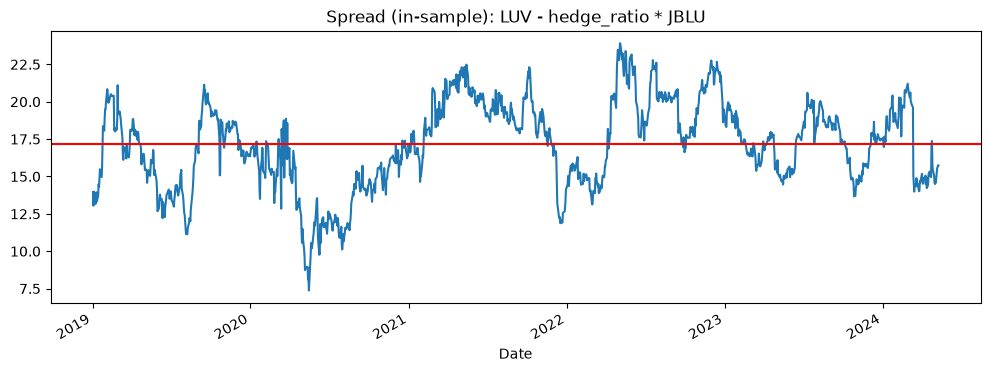

In [7]:
spread_in = in_sample[stock1] - hedge_ratio * in_sample[stock2]
spread_in.plot(figsize=(12,4), title="Spread (in-sample): LUV - hedge_ratio * JBLU")
plt.axhline(spread_in.mean(), color="red")
plt.show()

Now we convert these spreads into z-scores to see how many standard deviations away the spread is from the red line at a particular time.

z = (today's spread value - rolling average) / rolling standard deviation

to calculate the rolling average and rolling standard deviation, we take a 30 day lookback (reasonable, commonly used default)

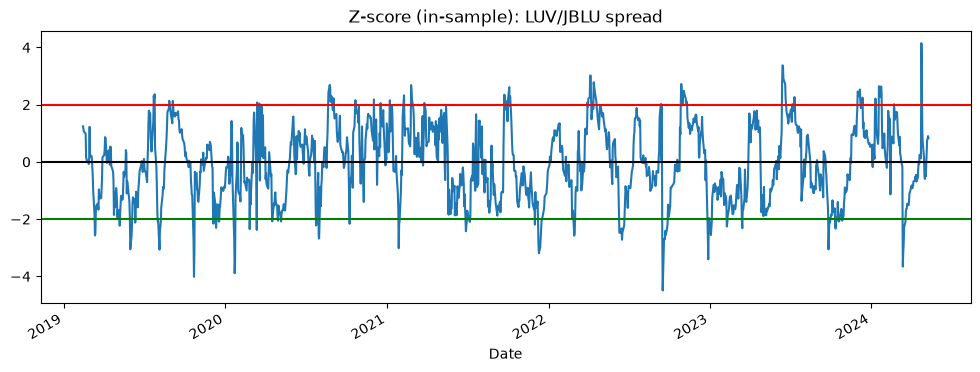

In [20]:
lookback = 30
rolling_mean = spread_in.rolling(lookback).mean()
rolling_std = spread_in.rolling(lookback).std()
zscore_in = (spread_in - rolling_mean) / rolling_std

zscore_in.plot(figsize=(12,4), title="Z-score (in-sample): LUV/JBLU spread")
plt.axhline(2, color="red")
plt.axhline(-2, color="green")
plt.axhline(0, color="black")
plt.show()

From above, the pattern looks encouraging as the oscillation around the mean (z-score = 0) look pretty consistent, excluding some signals reflecting single-day noise rather than a persistent, tradeable dislocation. (like towards the end).

Now, we backtest this by applying this strategy of pairs trading on the two stocks using the out_sample data, to see if it would be profitable. 

Making backtesting strategy..

In [29]:
def backtest_pair(prices1, prices2, hedge_ratio):
    spread = prices1 - hedge_ratio * prices2
    mean = spread.rolling(30).mean()
    std = spread.rolling(30).std()
    zscore = (spread - mean) / std

    position = 0 #bet for a particular day
    positions = []
    for z in zscore:
        if position == 0: #If we havent made a bet yet
            if z > 2:
                position = -1 #If spread has gone way too high, we bet on it to come down
            elif z < -2: 
                position = 1 #If spread has gone way too low, we bet on it to come up
        elif position == 1 and z >= 0: 
            position = 0 #If we had made a bet on the spread to come up and now the z-score is above or equal to 0, we close the position
        elif position == -1 and z <= 0:
            position = 0 #If we had made a bet on the spread to come down and now the z-score is below or equal to 0, we close the position
        positions.append(position) #Log each position for each day

    positions = pd.Series(positions, index=spread.index).shift(1) #Shift(1) is important to avoid look-ahead bias.
    spread_returns = spread.diff()
    strategy_returns = positions * spread_returns #payoff
    return strategy_returns, positions, zscore

strategy_returns_in, positions_in, zscore_in = backtest_pair(
    in_sample[stock1], in_sample[stock2], hedge_ratio
)

Running the function on out_sample data..

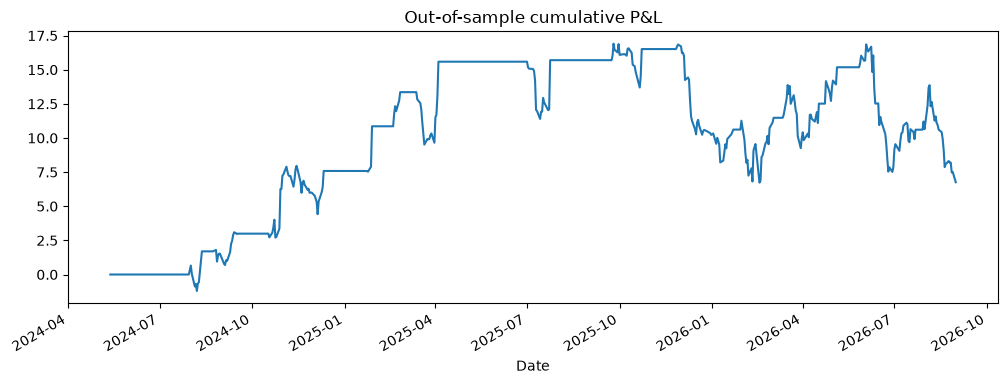

In [30]:
strategy_returns_out, positions_out, zscore_out = backtest_pair(
    out_sample[stock1], out_sample[stock2], hedge_ratio
)
cumulative_pnl = strategy_returns_out.cumsum()
cumulative_pnl.plot(figsize=(12,4), title="Out-of-sample cumulative P&L")
plt.show()

Healthy signal, Profit peaks at about 17.5%. Worth noting the pullback from late 2025 to late 2026, shows a limitation in the strategy. 

Now, calculating profits when accounting for transaction costs..

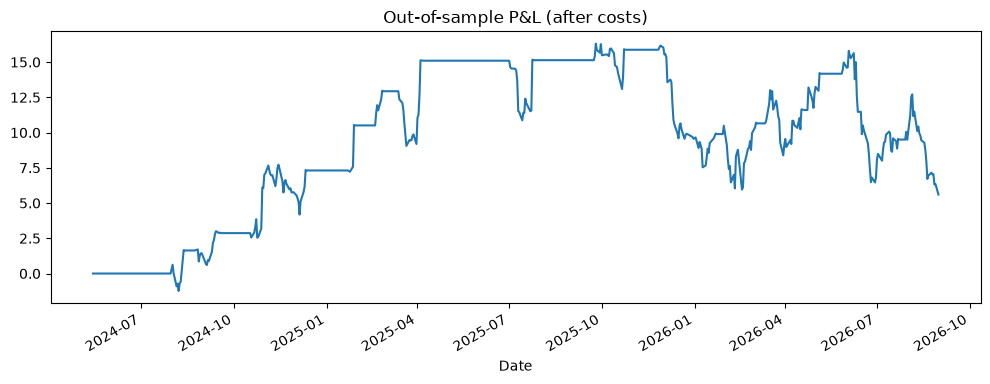

In [31]:
cost_per_trade = 0.001  # 10 bps
trades = positions_out.diff().abs()
transaction_costs = trades * cost_per_trade * (out_sample[stock1] + out_sample[stock2])
net_returns = strategy_returns_out - transaction_costs
net_cumulative_pnl = net_returns.cumsum()
net_cumulative_pnl.plot(figsize=(12,4), title="Out-of-sample P&L (after costs)")
plt.show()

Similar result - good signal. Transaction costs had minimal impact given the strategy's low trading frequency; a higher-frequency version of this approach would need to weigh costs more carefully.

Calculating Sharpe Ratio (to measure return relative to risk), Max Drawdown and Number of trades:

In [32]:
import numpy as np

sharpe = net_returns.mean() / net_returns.std() * np.sqrt(252)
max_drawdown = (net_cumulative_pnl - net_cumulative_pnl.cummax()).min()
num_trades = trades.sum()

print("Sharpe ratio:", round(sharpe, 2))
print("Max drawdown:", round(max_drawdown, 2))
print("Number of trades:", int(num_trades))

Sharpe ratio: 0.27
Max drawdown: -10.7
Number of trades: 29


Mediocre Sharpe ratio -> strategy made money on a risk-adjusted basis, but not a very compelling result.

Max drawdown of -10.7 on a peak ~15 cumulative P&L is a very large swing. Limitation of the strategy.

29 trades over ~2.5 years is a decent sample size, but more trades would make the strategy more trustworthy